# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Wendy Oosterhof
* Username: wroosterhof
* Student number: s6328091
* Group (AS1, etc.): AS6

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

Filename: ngc6946.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     205   (100, 100, 101)   float32   


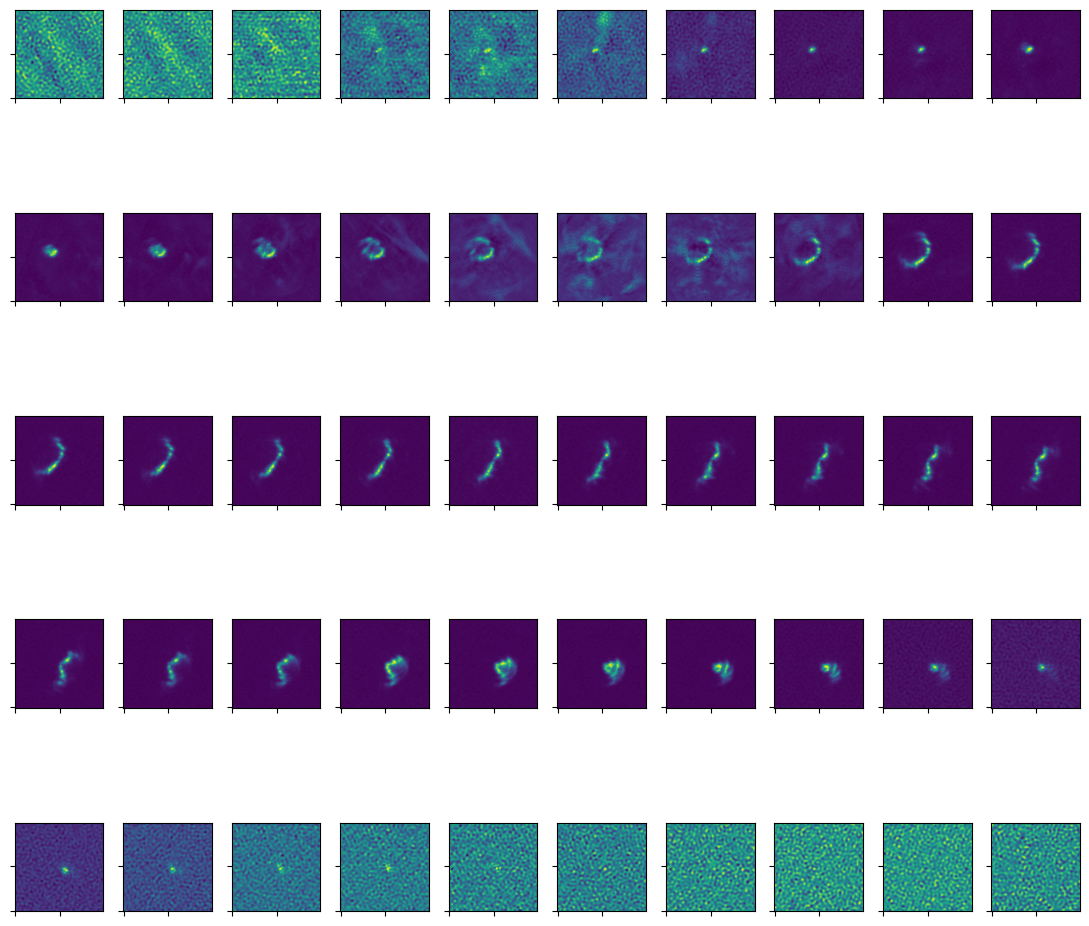

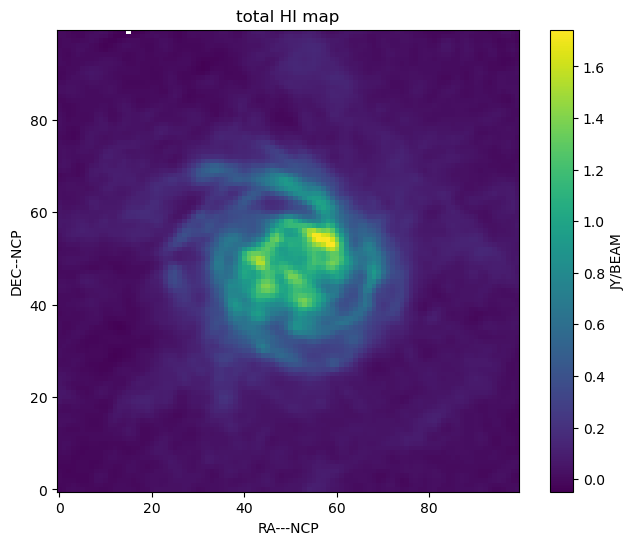

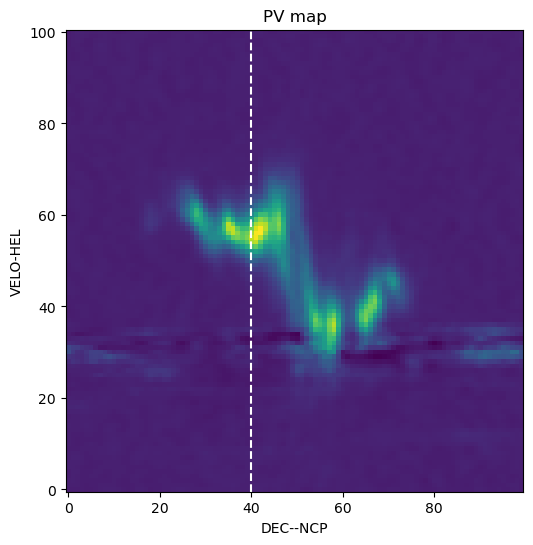

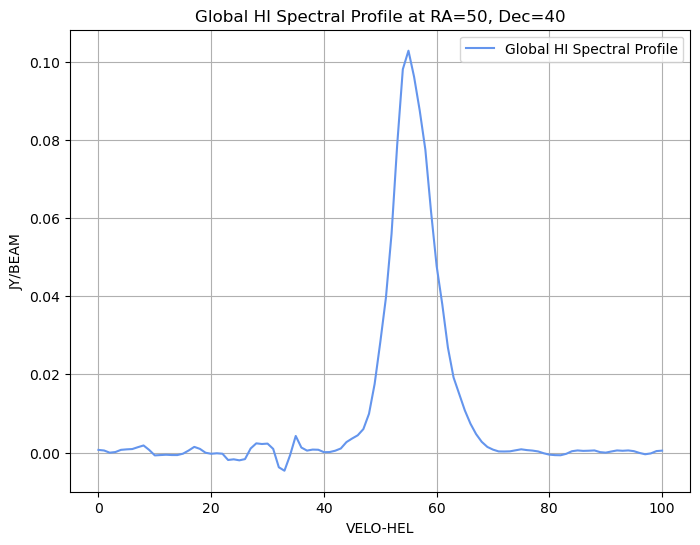

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits

#Importing the fits file.
hdulist = fits.open('ngc6946.fits')
dat = hdulist[0].data
hdulist.info()
hdr = hdulist[0].header



z_indices = range(1, 101, 2)

fig, axes = plt.subplots(5, 10, figsize=(11, 11)) #Creates the subplots with the 5 rows and 10 columns.


for i, z in enumerate(z_indices): #enumerates: gives both the item and its index while looping and setting the index to i, and the value to z.
    row = i//10 #Picks the row, by using an integer division which simulates how many rows of 10 have been filled.
    col = i%10 #Picks the column by finding the i modulo 10. i = 10 would give 0, so the very first column, while i = 49 has a modulo of 9, so the last column.
    #Plotting within the loop.
    ax = axes[row, col] #General axes formula, so you don't have to use axes[0,1] and axes[1,1] etc.
    ax.imshow(dat[z,:,:], origin = "lower") #Plots a singular graph in its assigned subplot.
    ax.set_xticklabels([])
    ax.set_yticklabels([])

plt.tight_layout() #Makes the graphs look cleaner together.
plt.show()

##TOTAL HI MAP.
#Choosen range: frame 10 till frame 38, started counting at 1.
z_range = range(21,75) #Sets the range for z.
channelsum = np.sum(dat[z_range,:,:], axis = 0) #Calculates the sum of the data.
#Axis = 0 is for the z-axis!

#Plotting the first graph.
fig = plt.figure(figsize = (8,6))
frame = fig.add_subplot(1,1,1)
plt.imshow(channelsum, origin = "lower")
#Setting axes labels.
frame.set_xlabel(hdr["CTYPE1"])
frame.set_ylabel(hdr["CTYPE2"])
frame.set_title("total HI map")
plt.colorbar(label = hdr["BUNIT"]) #Plotting colorbar.
plt.show()

##PV MAP.
pv_map = dat[:, :, 50] #Slices at RA = 50.

#Plotting PV map.
fig = plt.figure(figsize = (8,6))
frame = fig.add_subplot(1,1,1)
plt.imshow(pv_map, origin = "lower")
plt.axvline(x=40, color='white', linestyle='--', label='Dec index 40') #Plots the vertical line as dec index 40 (x).
frame.set_xlabel(hdr["CTYPE2"])
frame.set_ylabel(hdr["CTYPE3"])
frame.set_title("PV map")
plt.show()

##GLOBAL HI SPECTRAL PROFILE.
profile = dat[:,40,50] #Slicing the data for given specifications.

#Plotting global HI spectral profile.
fig = plt.figure(figsize = (8,6))
frame = fig.add_subplot(1,1,1)
plt.plot(profile, color = "cornflowerblue", label = "Global HI Spectral Profile")
frame.set_xlabel(hdr["CTYPE3"])
frame.set_ylabel(hdr["BUNIT"])
frame.set_title("Global HI Spectral Profile at RA=50, Dec=40")
frame.legend()
frame.grid()
plt.show()


hdulist.close()

The relation is that the Peak of the graph is around the same velocity as the yellow parts of the PV map.

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

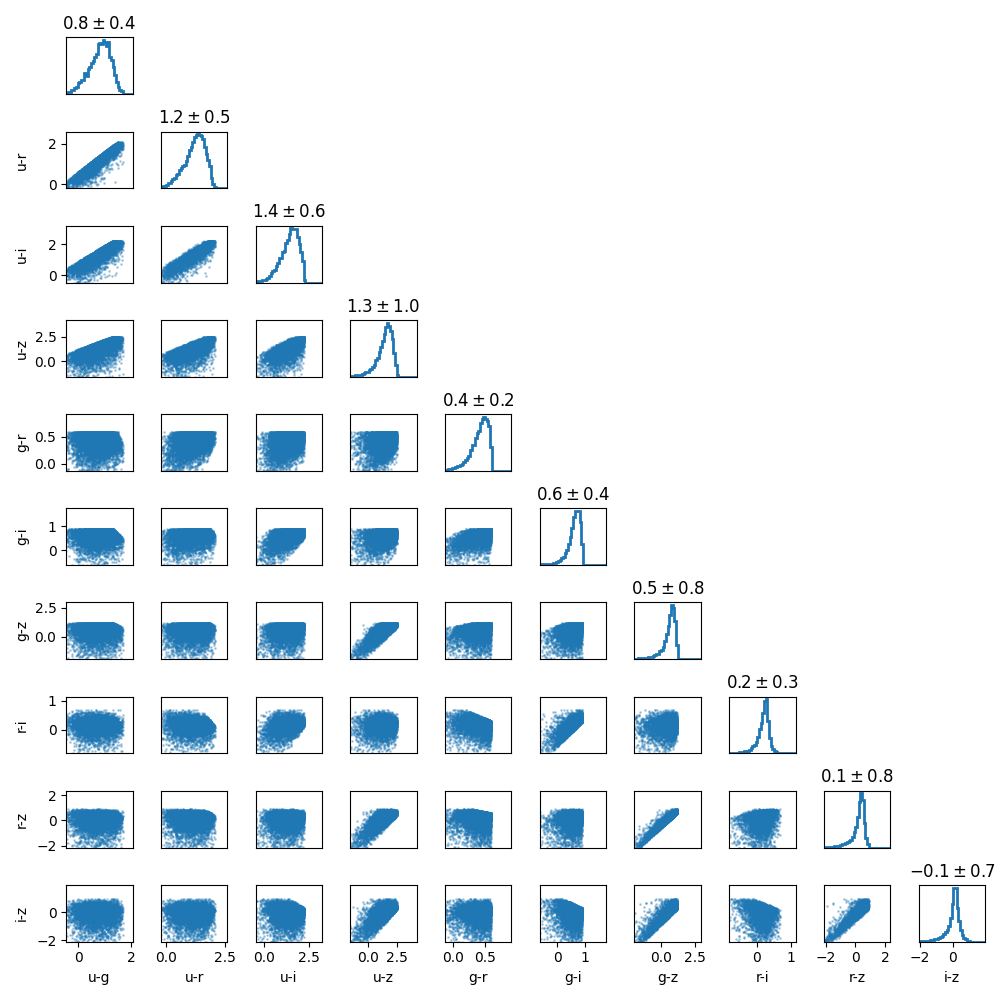
   
**Plot and answer**:

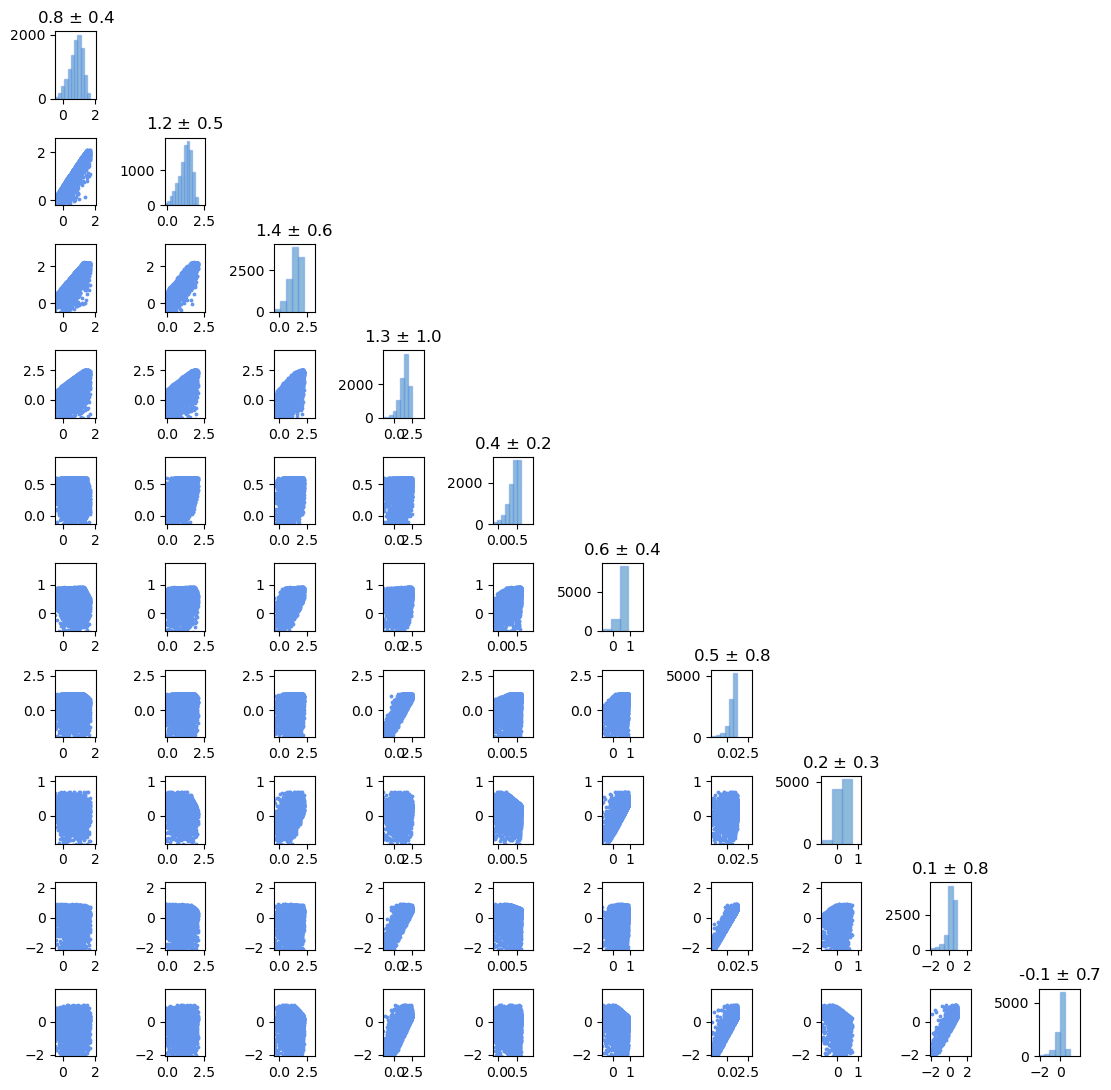

In [2]:
from astropy.table import Table
from astropy.io import fits

hdul = fits.open('SDSS_DR17_galaxies.fits')
table = Table(hdul[1].data)   #Converts the table of the fits to an astropy table, later used to change it into pandas.
df = table.to_pandas()

#Mask making:
mask = (
    (df['u'] >= 0) &
    (df['g'] >= 0) &
    (df['r'] >= 0) &
    (df['i'] >= 0) &
    (df['z'] >= 0)
)

df_clean = df[mask] #Applies said mask.

bands = ['u', 'g', 'r', 'i', 'z'] #Lets us loop over the bands.

col_names = []

for i in range(len(bands)):
    for j in range(i+1, len(bands)):
        colname = f"{bands[i]}-{bands[j]}"
        df_clean[colname] = df_clean[bands[i]] - df_clean[bands[j]]
        col_names.append(colname)

#Making dictionaries.
means = {}
stds = {}

#looping over the col_names list to make sure every option is taken care of.
for col in col_names:
    means[col] = df_clean[col].mean() #Adds the mean with their respective colorband to the dictionary.
    stds[col] = df_clean[col].std() #Does the same as the line above, but then for the standard deviation.

fig, axes = plt.subplots(10, 10, figsize=(11, 11)) #Creates the subplots with the 10 rows and 10 columns.

for i in range(0,100):
    row = i // 10
    col = i % 10
    ax = axes[row, col] #Setting the axes.
    if col > row: #If the column is higher than the row number, we don't want the plot to show.
        ax.set_visible(False) #Makes all the axes of the uppertriangle invisible.

    #Just for less typing and a bit of simplification.
    a = col_names[row] 
    b = col_names[col]

    #Diagonal.
    if row == col: #If the row is the same number as the column, we want an histogram (it lies on the diagonal).
        ax.hist(df_clean[a], bins=25, alpha = 0.5, edgecolor="cornflowerblue") #Plotting the histogram.
        ax.set_xlim(means[a] - 3*stds[a], means[a] + 3*stds[a]) #Setting the x-axis.
        #No y axis specified since that happens quite well in a histogram.
        ax.set_title(rf"{means[a]:.1f} $\pm$ {stds[a]:.1f}") #Setting the title.
        
    #Lower triangle.
    elif row > col: #If the row is lower than the column, we want a scatter plot.
        ax.scatter(df_clean[b], df_clean[a], s=3, color="cornflowerblue") #Makes said scatterplot.
        ax.set_xlim(means[b] - 3*stds[b], means[b] + 3*stds[b]) #Sets the x-axis.
        ax.set_ylim(means[a] - 3*stds[a], means[a] + 3*stds[a]) #Sets the y-axis.
plt.tight_layout() #Makes the graphs not overlap.
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

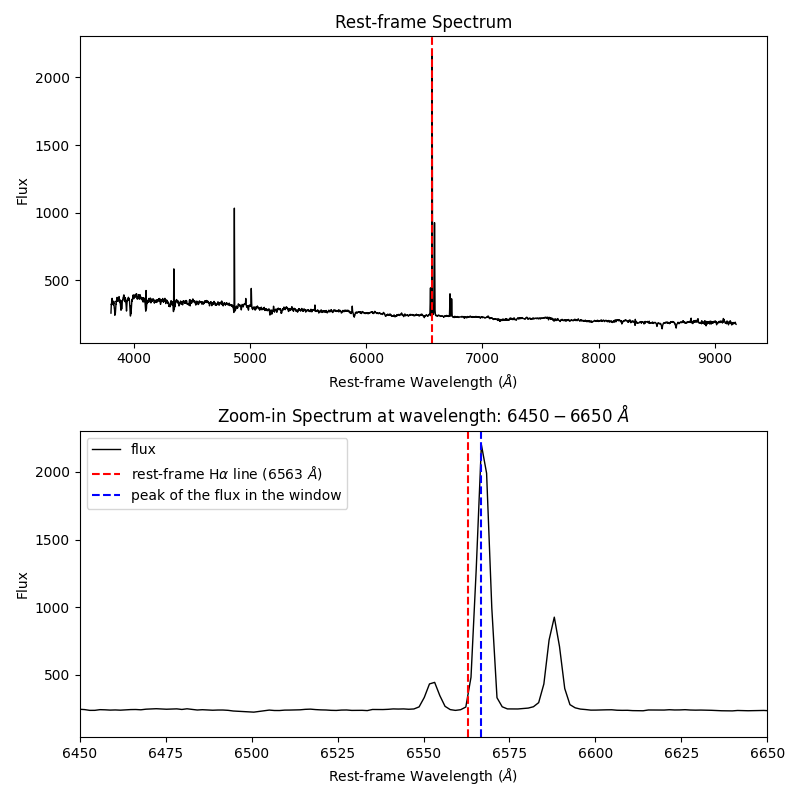

In [ ]:
%pip install astroquery

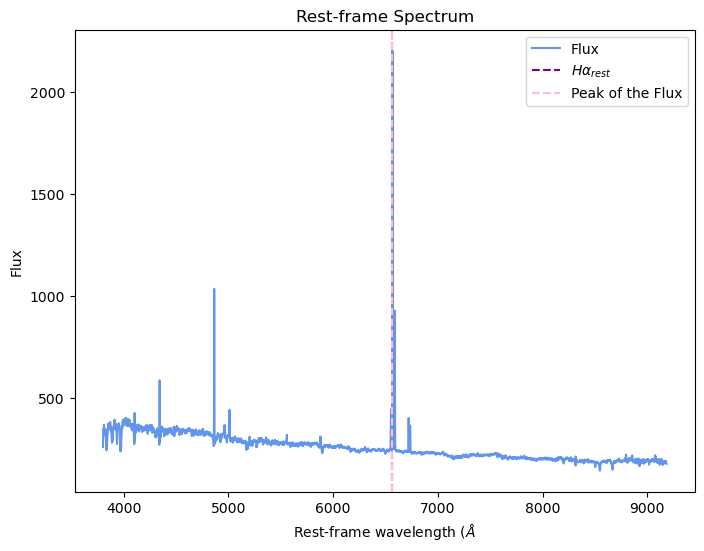

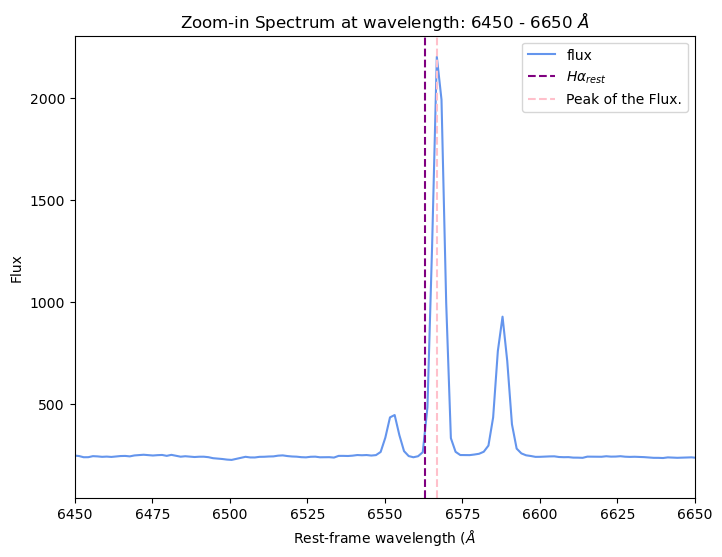

The velocity is: 173.02 km/s


In [3]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
from matplotlib import pyplot as plt
import numpy as np

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
radius = 10 * u.arcsec  # search radius
obj_table = SDSS.query_region(pos, radius=radius, spectro=True)
spectra_list = SDSS.get_spectra(matches = obj_table)

#print(f"Retrieved {len(spectra_list)} spectra.") -> Used to check in between and as a checkpoint.

spec = spectra_list[0]
data = spec[1].data
#print(data.columns)  # lists the columns. -> Used to check in between and to find the needed columns (for if they had more complicated names).

flux = data["flux"]
loglam = data["loglam"]
wavelength = 10**loglam  #Converts from log10(lambda) to Angstrom (10E-10 m)

z = 0.0038
Lambda_rest = wavelength / (1 + z) #Calculating the rest-frame wavelengths (Lambda_rest).
#Formula: lambda_rest = lambda_obs / (1 + z)
x_peak = Lambda_rest[np.argmax(flux)] #Getting the peak coordinate for the x-axis.



fig = plt.figure(figsize = (8,6))
frame = fig.add_subplot(1,1,1)
plt.plot(Lambda_rest, flux, label = "Flux", color = "cornflowerblue")
frame.set_title("Rest-frame Spectrum")
frame.set_xlabel(r"Rest-frame wavelength ($\AA$")
frame.set_ylabel("Flux")
frame.axvline(x = 6563, color = "purple", linestyle = "--", label = r"$H\alpha_{rest}$") 
frame.axvline(x = x_peak, color = "pink", linestyle = "--", label = "Peak of the Flux")
#The pink line is almost on top of the purple one, so that's why only one is shown in the plot. The other one is there just hidden!
frame.legend()
plt.show()

fig = plt.figure(figsize = (8, 6))
frame = fig.add_subplot(1,1,1)
plt.plot(Lambda_rest, flux, label = "flux", color = "cornflowerblue")
frame.set_xlim(6450,6650)
frame.set_title(r"Zoom-in Spectrum at wavelength: 6450 - 6650 $\AA$")
frame.set_xlabel(r"Rest-frame wavelength ($\AA$")
frame.set_ylabel("Flux")
frame.axvline(x = 6563, color = "purple", linestyle = "--", label = r"$H\alpha_{rest}$")
frame.axvline(x = x_peak, color = "pink", linestyle = "--", label = "Peak of the Flux.")
frame.legend()
plt.show()

c = 3e5  # km/s (Speed of light).

lambda_0 = 6563  # rest Hα, in Angstrom.
z_offset = (x_peak - lambda_0) / lambda_0 #Since the offset doesn't have units (Angstrom/Angstrom) we don't have to convert the wavelengths.

v = c * z_offset #Calculates the velocity.
print(f"The velocity is: {v:.2f} km/s") #Prints said velocity.


This small offset could be a result of equipment usage, calibration or limitations, or could be a result of rotation of the galaxy, leading to a difference in the redshift from one side to another.

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

/Users/users/wroosterhof/PROGNUM-repo/Task6/20210422_Li_.00000066.FIT


/opt/anaconda-hub/lib/python3.13/site-packages/astropy/visualization/stretch.py:543: RuntimeWarning: overflow encountered in sinh
  np.sinh(values, out=values)
/opt/anaconda-hub/lib/python3.13/site-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


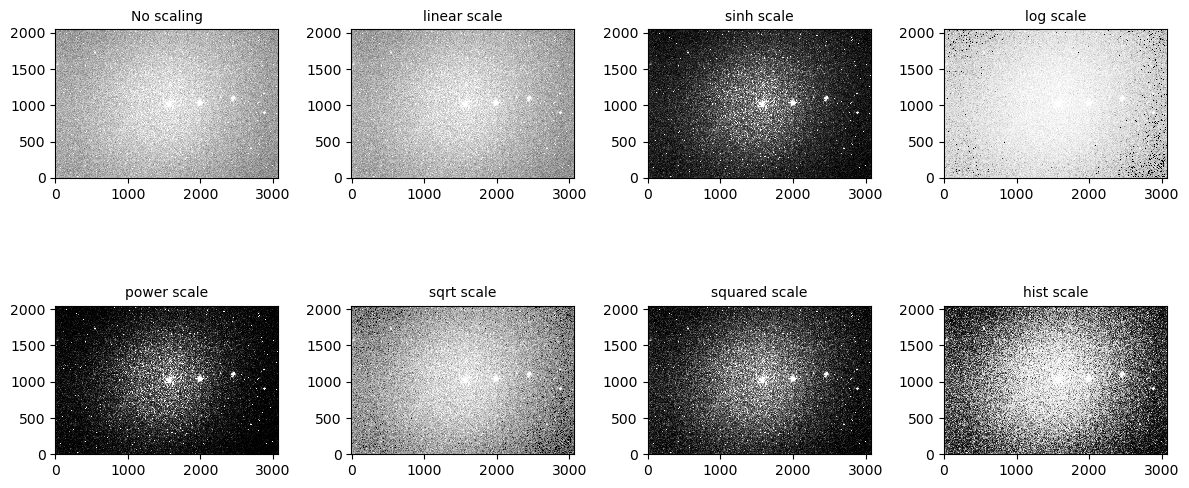

In [4]:
from pathlib import Path
import os
from astropy.io import fits
from matplotlib import pyplot as plt
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval

home = Path.home()
datapath = Path("PROGNUM-repo/Task6/20210422_Li_.00000066.FIT")
path = home / datapath
print(path)

hdulist = fits.open(path)
image_data = hdulist[0].data
if 'int' in str(image_data.dtype):
    image_data = image_data.astype('float')


def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    """
    Display a 2D image with configurable intensity scaling and normalization.
    The function allows different stretch methods to enhance image contrast,
    and automatically determines good intensity limits if not provided.
    """
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

stretches = ["linear", "sinh", "log", "power", "sqrt", "squared", "hist"]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

# First plot: no scaling
imdisplay(image_data, axes[0], scale='linear')
axes[0].set_title("No scaling", fontsize=10)

# Remaining plots
for i in range(len(stretches)):
    imdisplay(image_data, axes[i+1], scale = stretches[i], power = 3)
    axes[i+1].set_title(f"{stretches[i]} scale", fontsize=10)


plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

In [ ]:
%pip install astroalign

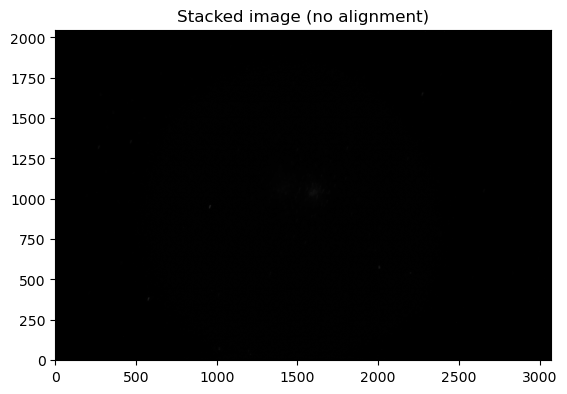

Target: /Users/users/wroosterhof/VIRGO01/Data/i/20210418_Li_.00000044.FIT
Aligning: /Users/users/wroosterhof/VIRGO01/Data/i/20210418_Li_.00000055.FIT
Failed
Aligning: /Users/users/wroosterhof/VIRGO01/Data/i/20210418_Li_.00000052.FIT
Failed
Aligning: /Users/users/wroosterhof/VIRGO01/Data/i/20210418_Li_.00000060.FIT
Failed
Aligning: /Users/users/wroosterhof/VIRGO01/Data/i/20210418_Li_.00000036.FIT
Aligning: /Users/users/wroosterhof/VIRGO01/Data/i/20210418_Li_.00000043.FIT
Aligning: /Users/users/wroosterhof/VIRGO01/Data/i/20210418_Li_.00000038.FIT
Aligning: /Users/users/wroosterhof/VIRGO01/Data/i/20210418_Li_.00000044.FIT
Aligning: /Users/users/wroosterhof/VIRGO01/Data/i/20210418_Li_.00000061.FIT
Failed
Aligning: /Users/users/wroosterhof/VIRGO01/Data/i/20210418_Li_.00000053.FIT
Failed
Aligning: /Users/users/wroosterhof/VIRGO01/Data/i/20210418_Li_.00000054.FIT
Failed
Aligning: /Users/users/wroosterhof/VIRGO01/Data/i/20210418_Li_.00000039.FIT
Aligning: /Users/users/wroosterhof/VIRGO01/Data/

In [5]:
from pathlib import Path
import os
from astropy.io import fits
from matplotlib import pyplot as plt
from matplotlib.pyplot import subplots, show
import numpy as np
import astroalign as aa

datadir = "/Users/users/wroosterhof/VIRGO01/Data/i"  #Data folder
excludes = ['BIAS', 'FLAT', 'DARK']  # Exclude these images if these are opart of the file name

path = Path(datadir)
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)

data_list = []  # This will hold the image/data arrays.

for filepath in filepaths:
    with fits.open(filepath) as hdul:
        data = hdul[0].data  # Get the data from the primary HDU.
        data_list.append(data)

#Non-aligned stacking:
stacked = np.stack(data_list, axis=0) #Stacking the given data.
meanstack = np.mean(stacked, axis=0) #Taking the mean of the stacked data to be able to plot it.

# Plot result
plt.imshow(meanstack, origin='lower', cmap='gray')
plt.title("Stacked image (no alignment)")
plt.show()


target = filepaths[6]
print(f"Target: {target}")
hdulist = fits.open(target)
target_im = hdulist[0].data.astype('float')

images = []
for filepath in filepaths:
    if not filepath.name in excludes:
        print(f"Aligning: {filepath}")
        hdulist = fits.open(filepath)
        tobealigned_im = hdulist[0].data.astype('float')
        try:
            aligned_im, footprint = aa.register(tobealigned_im,
                                                target_im,
                                                detection_sigma=5.0,
                                                max_control_points=100,
                                                min_area=5)
            images.append(aligned_im)
        except:
            print("Failed")
        hdulist.close()




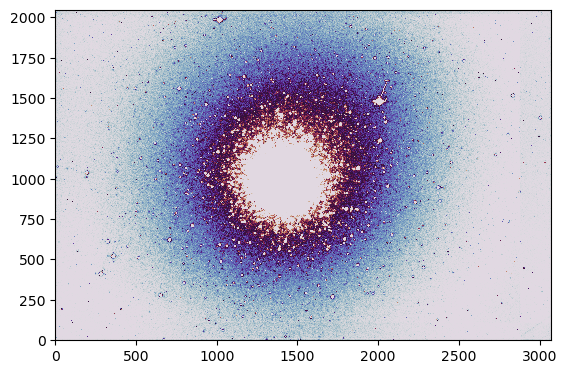

In [6]:
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval

aligned_stacked = np.stack(images, axis = 0)
stacked_mean_al = np.mean(aligned_stacked, axis=0)

def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

from matplotlib.pyplot import subplots, show

fig, ax = subplots()
imdisplay(np.flipud(stacked_mean_al), ax, percentlow=5, percenthigh=95,
          scale='squared', cmap='twilight')
show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")